# Demo: Using the ML modeling API


- In this notebook, we will walk through a few transformations that are included in the Snowpark ML Preprocessing API. 
- We will also build a preprocessing pipeline to be used in the third notebook.

***Note: All feature transformations using Snowpark ML are distributed operations in the same way that Snowpark DataFrame operations are.***

<a id="topics"></a>
### Topics in this Lesson



1. [Setup](#Setup)  
    1. [Import Libraries](#Import_Libraries)   
    1. [Connect and create a Session](#Connect_and_create_a_Session)
1. [Data Ingestion](#Data_Ingestion)  
    1. [Use the Snowpark DataFrame Reader to read in data from the externally staged TXT file](#Snowpark_DataFrame_Reader)  
    1. [Save the DataFrame to a Snowflake table](#Write_data)  
1. [Transforming data](#Transforming_data)   
    1. [Feature Transformations](#Feature_Transformations) 
        1. [MinMaxScaler](#MinMaxScaler) 
        1. [OrdinalEncoder](#OrdinalEncoder) 
        1. [Custom Transformer](#customtransformer) 
        1. [OneHotEncoder](#OneHotEncoder) 
    1. [OneHotEncoder](#OneHotEncoder) 
1. [Data Exploration](#Data_Exploration) 
        
     
    

<a id="Setup"></a>
## 1. Setup

<a id="Import_Libraries"></a>
### 1.1 Import Libraries

In [1]:
# Snowpark for Python
from snowflake.snowpark import Session
from snowflake.snowpark.version import VERSION
import snowflake.snowpark.functions as F
from snowflake.snowpark.types import DecimalType, DoubleType

# Snowpark ML
import snowflake.ml.modeling.preprocessing as SNOWML
from snowflake.ml.modeling.pipeline import Pipeline
from snowflake.ml.modeling.metrics.correlation import correlation

# Data Science Libs
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Misc
import json
import joblib

# warning suppresion
import warnings; warnings.simplefilter('ignore')

/Users/richardkirk/SourceCode/snowflake-datasciencelabs-jupyter/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<a id="Connect_and_create_a_Session"></a>
### 1.2 Connect and create a `Session`

The following cell connects to your Snowflake account and creates an instance of `Session`. 

*You needn't modify anything in this cell. Just run it.*
> &#10071; **Success requires that you have already completed the key pair authentication notebook in UTILS.**

In [2]:
# MyNote: need to: pip install nbformat 
# for this to work, even though it's possible to run the utils/ds_utils_python.ipynb directly without nbformat library

# # Run utils notebook
%run ../../utils/ds_utils_python_MINE.ipynb

# # Connect to Snowflake and create a Session object named session
# session = create_session()

In [3]:
# My code for Snowflake account connection

CONFIG_DIR = '/Users/richardkirk/.ssh'
CONFIGFILE = CONFIG_DIR + '/sf_config'


# Load configuration file
with open(CONFIGFILE) as f:
    lines = f.readlines()
    
# Convert configuration to a properties map
props = {}
for line in lines:
    (key, value) = line.split('=')
    props.update({key.lower() : value[0:-1]})
    
# Convert the private key to a DER-encoded bytes object
from cryptography.hazmat.primitives import serialization
from cryptography.hazmat.backends import default_backend

with open(props['private_key_file'], "rb") as key:
    private_key = serialization.load_pem_private_key(
        key.read(),
        password=None,
        backend=default_backend()
    )
    
private_key_bytes = private_key.private_bytes(
    encoding=serialization.Encoding.DER,
    format=serialization.PrivateFormat.PKCS8,
    encryption_algorithm=serialization.NoEncryption()
)

# Connect to Snowflake
session = Session.builder.configs({**props, **{"private_key": private_key_bytes}}).create()

In [4]:
# Hard code the lesson name
lesson_name = "SNOWFLAKE_ML_PY"

# Create the context items for this lesson
lesson = confirm_or_create_lesson_context(session, lesson_name)

Creation of context items could take a few moments... be patient
The current user is: RKIRK
Query tag is: Data Science: RKIRK - SNOWFLAKE_ML_PY
-------------------------------------------------
|"Created warehouse RKIRK_WH"                   |
-------------------------------------------------
|RKIRK_WH already exists, statement succeeded.  |
-------------------------------------------------

------------------------------------
|"Altered warehouse RKIRK_WH"      |
------------------------------------
|Statement executed successfully.  |
------------------------------------

Setting current warehouse to RKIRK_WH
Creating database RKIRK_DB
-------------------------------------------------
|"Created database RKIRK_DB"                    |
-------------------------------------------------
|RKIRK_DB already exists, statement succeeded.  |
-------------------------------------------------

Creating schema SNOWFLAKE_ML_PY_LESSON
-------------------------------------------------------
|"Create

In [5]:
snowflake_environment = session.sql('SELECT current_user(), current_version()').collect()
snowpark_version = VERSION
current_database = session.get_current_database()
current_schema = session.get_current_schema()
# Current Environment Details
print('\nConnection Established with the following parameters:')
print('User                        : {}'.format(snowflake_environment[0][0]))
print('Role                        : {}'.format(session.get_current_role()))
print('Database                    : {}'.format(session.get_current_database()))
print('Schema                      : {}'.format(session.get_current_schema()))
print('Warehouse                   : {}'.format(session.get_current_warehouse()))
print('Snowflake version           : {}'.format(snowflake_environment[0][1]))
print('Snowpark for Python version : {}.{}.{}'.format(snowpark_version[0],snowpark_version[1],snowpark_version[2]))


Connection Established with the following parameters:
User                        : RKIRK
Role                        : "ACCOUNTADMIN"
Database                    : "RKIRK_DB"
Schema                      : "SNOWFLAKE_ML_PY_LESSON"
Warehouse                   : "RKIRK_WH"
Snowflake version           : 10.18.101
Snowpark for Python version : 1.50.1



<a id="Data_Ingestion"></a>
## 2. Data Ingestion

The `diabetes` dataset has been widely used in data science and machine learning. We will use it to demonstrate Snowflake's native data science transformers in terms of database functionality and Spark & Pandas comportablity, using non-synthetic and statistically appropriate data that is well known to the ML community.


**&#128221; Note:** To show some parts of the Modeling API, we made some changes to this dataset, such as changing the BMI into categorical values.



In [6]:
# Create a variable for the Friends JSON file name
diabetes_txt_file_name = "diabetes.txt"
stage_name = "DEMO_STAGE"
full_stage_name = f"{current_database}.{current_schema}.{stage_name}";

# Create the stage if it doesn't already exist
(session.sql(f"CREATE STAGE IF NOT EXISTS {full_stage_name}")
    .show()
)    

print(f"The fully-qualified stage name is: {full_stage_name}")

# Use a FileOperation object to put the file into a stage
put_results_list = (
    session
        .file                         # Creates the FileOperation object
        .put(                         # Perform a PUT
             diabetes_txt_file_name   # Name of file to put 
            ,full_stage_name          # Desired stage and path for the file
            ,auto_compress = False    # Configure desired compression
            ,overwrite = True         # Configure behavior if filename already exists
         )
)

# List the stage contents
session.sql(f'list @{full_stage_name}').show()

-----------------------------------------------
|"status"                                     |
-----------------------------------------------
|Stage area DEMO_STAGE successfully created.  |
-----------------------------------------------

The fully-qualified stage name is: "RKIRK_DB"."SNOWFLAKE_ML_PY_LESSON".DEMO_STAGE
-------------------------------------------------------------------------------------------------------
|"name"                   |"size"  |"md5"                             |"last_modified"                |
-------------------------------------------------------------------------------------------------------
|demo_stage/diabetes.txt  |22416   |0f64fb28b3ca043dc5105325badf6f65  |Thu, 21 May 2026 05:25:50 GMT  |
-------------------------------------------------------------------------------------------------------



MyNote: The above cell loads data file here
```sql
list @"RKIRK_DB"."SNOWFLAKE_ML_PY_LESSON".DEMO_STAGE;
```

<a id="Snowpark_DataFrame_Reader"></a>
### 2.1 Use the Snowpark DataFrame Reader to read in data from the externally staged `diamonds` TXT file 

We staged the `diabetes_categories.txt` file. Use the Snowpark DataFrame Reader to read data from cloud storage.

For more information on loading data, see documentation on [snowflake.snowpark.DataFrameReader](https://docs.snowflake.com/ko/developer-guide/snowpark/reference/python/api/snowflake.snowpark.DataFrameReader.html).


The diabetes file is a .txt file with no schema. We will create one for the DataFrame that will work with that data.

In [7]:
from snowflake.snowpark.types import StructType, StructField, IntegerType, StringType

schema = (
    StructType(
        [
             StructField("AGE", IntegerType())
            ,StructField("SEX", StringType()) 
            ,StructField("BMI", StringType())
            ,StructField("BP", IntegerType())
            ,StructField("BLOOD_SERUM1", IntegerType()) 
            ,StructField("BLOOD_SERUM2", IntegerType()) 
            ,StructField("BLOOD_SERUM3", IntegerType()) 
            ,StructField("BLOOD_SERUM4", IntegerType()) 
            ,StructField("BLOOD_SERUM5", IntegerType()) 
            ,StructField("BLOOD_SERUM6", IntegerType()) 
            ,StructField("TARGET", IntegerType())
            
        ]
     )
)

In [8]:
# Create a full file path to the Diabetes TXT file
diabetes_TXT_file_path = f"@{full_stage_name}/{diabetes_txt_file_name}"

print(f"The full path to the diabetes txt file is {diabetes_TXT_file_path}")

# Create a DataFrame from the file data
diabetes_df = (
    session
        .read
        .schema(schema)
        .option('SKIP_HEADER', 1)
        .option('FIELD_DELIMITER', '\t')
        .csv(diabetes_TXT_file_path)
)

The full path to the diabetes txt file is @"RKIRK_DB"."SNOWFLAKE_ML_PY_LESSON".DEMO_STAGE/diabetes.txt


In [9]:
diabetes_df.show()

-------------------------------------------------------------------------------------------------------------------------------------------------------
|"AGE"  |"SEX"   |"BMI"       |"BP"  |"BLOOD_SERUM1"  |"BLOOD_SERUM2"  |"BLOOD_SERUM3"  |"BLOOD_SERUM4"  |"BLOOD_SERUM5"  |"BLOOD_SERUM6"  |"TARGET"  |
-------------------------------------------------------------------------------------------------------------------------------------------------------
|59     |Female  |obese       |101   |157             |93              |38              |4               |49              |87              |151       |
|48     |Male    |normal      |87    |183             |103             |70              |3               |39              |69              |75        |
|72     |Female  |obese       |93    |156             |94              |41              |4               |47              |85              |141       |
|24     |Male    |overweight  |84    |198             |131             |40              

<a id="Write_data"></a>
### 2.2 Save the DataFrame to a Snowflake table

In [10]:
diabetes_df.write.mode('overwrite').save_as_table(f"{current_database}.{current_schema}.diabetes")

MyNote: saves data here;
```sql
select top 10 * from RKIRK_DB.SNOWFLAKE_ML_PY_LESSON.DIABETES;
```

<a id="Transforming_data"></a>
## 3. Transforming data

<a id="Feature_Transformations"></a>
### 3.1 Feature Transformations

We will illustrate a few of the transformation functions here.

Currently Snowflake supports the following preprocessing classes, found in API module `snowflake.ml.modeling.preprocessing`:

- `StandardScaler` Standardizes features by removing the mean and scaling to unit variance.
- `OrdinalEncoder` Encodes categorical features as an integer array.
- `MixMaxScaler`   Transforms features by scaling each feature to a given range.
- `LabelEncoder`   Encodes target labels with values between 0 and n_classes-1.
- `RobustScaler`   Scales features using statistics that are robust to outliers.
- `KBinsDiscretizer` Bin continuous data into intervals.
- `MaxAbsScaler`   Scale each feature by its maximum absolute value.
- `Normalizer`     Normalize samples individually to each row's unit norm.
- `OneHotEncoder`  Encode categorical features as a one-hot numeric array.
- `Binzarizer`     Binarizes data (sets feature values to 0 or 1) according to the given threshold.
- `PolynomialFeatures` Generate polynomial and interaction features, [sklearn.preprocessing.PolynomialFeatures](https://docs.snowflake.com/en/developer-guide/snowpark-ml/reference/1.2.0/modeling#snowflake-ml-modeling-preprocessing:~:text=Generate%20polynomial%20and%20interaction%20features%20For%20more%20details%20on%20this%20class%2C%20see%20sklearn.preprocessing.PolynomialFeatures)

For more info, check the [documentation](https://docs.snowflake.com/LIMITEDACCESS/snowflake-ml-preprocessing).

<a id="MinMaxScaler"></a>
### 3.1.1 MinMaxScaler

##### Let's use the `MinMaxScaler` to normalize the `BLOOD_SERUM` columns.

In [11]:
# Normalize the CARAT column
snowml_mms = (SNOWML.MinMaxScaler(
    input_cols=["BLOOD_SERUM1", "BLOOD_SERUM2", "BLOOD_SERUM3", "BLOOD_SERUM4", "BLOOD_SERUM5", "BLOOD_SERUM6"], 
    output_cols=["BS1", "BS2", "BS3", "BS4", "BS5", "BS6"])
             )
normalized_diabetes_df = snowml_mms.fit(diabetes_df).transform(diabetes_df)

#normalized_diabetes_df.show()
normalized_diabetes_df.select("BS4", "BLOOD_SERUM4").show()

----------------------------------------
|"BS4"                |"BLOOD_SERUM4"  |
----------------------------------------
|0.28571428571428570  |4               |
|0.14285714285714285  |3               |
|0.28571428571428570  |4               |
|0.42857142857142855  |5               |
|0.28571428571428570  |4               |
|0E-17                |2               |
|0.14285714285714285  |3               |
|0.42857142857142855  |5               |
|0.28571428571428570  |4               |
|0.28571428571428570  |4               |
----------------------------------------



In [12]:
# Reduce the number of decimals 
normalized_diabetes_df = (normalized_diabetes_df
                          .with_column("BS1", F.col("BS1").cast(DecimalType(7,4)))
                          .with_column("BS2", F.col("BS2").cast(DecimalType(7,4)))
                          .with_column("BS3", F.col("BS3").cast(DecimalType(7,4)))
                          .with_column("BS4", F.col("BS4").cast(DecimalType(7,4)))
                          .with_column("BS5", F.col("BS5").cast(DecimalType(7,4)))
                          .with_column("BS6", F.col("BS6").cast(DecimalType(7,4)))
                         )

In [13]:
normalized_diabetes_df.show()

-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
|"AGE"  |"SEX"   |"BMI"       |"BP"  |"BLOOD_SERUM1"  |"BLOOD_SERUM2"  |"BLOOD_SERUM3"  |"BLOOD_SERUM4"  |"BLOOD_SERUM5"  |"BLOOD_SERUM6"  |"TARGET"  |"BS1"   |"BS2"   |"BS3"   |"BS4"   |"BS5"   |"BS6"   |
-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
|59     |Female  |obese       |101   |157             |93              |38              |4               |49              |87              |151       |0.2941  |0.2550  |0.2078  |0.2857  |0.7895  |0.4394  |
|48     |Male    |normal      |87    |183             |103             |70              |3               |39              |69              |75        |0.4216  |0.3050  |0.6234 

<a id="OrdinalEncoder"></a>
### 3.1.2 OrdinalEncoder

##### The value of the labels for body mass index have a meaningful order, so let's use the `OrdinalEncoder` to transform `BMI` from categorical to numerical values so they are more useful for modeling.

In [14]:
# Encode BMI to preserve ordinal importance
categories = {
    "BMI": np.array(["underweight", "normal", "overweight", "obese", "extremely_obese"])
}
snowml_oe = SNOWML.OrdinalEncoder(input_cols=["BMI"], output_cols=["BMI_OE"], categories=categories)
ord_encoded_diabetes_df = snowml_oe.fit(normalized_diabetes_df).transform(normalized_diabetes_df)

# Show the encoding
print(snowml_oe._state_pandas)

#ord_encoded_diabetes_df.show()
ord_encoded_diabetes_df.select("BMI", "BMI_OE").show()

  _COLUMN_NAME        _CATEGORY  _INDEX
0          BMI      underweight       0
1          BMI           normal       1
2          BMI       overweight       2
3          BMI            obese       3
4          BMI  extremely_obese       4
---------------------
|"BMI"   |"BMI_OE"  |
---------------------
|normal  |1.0       |
|normal  |1.0       |
|normal  |1.0       |
|normal  |1.0       |
|normal  |1.0       |
|normal  |1.0       |
|normal  |1.0       |
|normal  |1.0       |
|normal  |1.0       |
|normal  |1.0       |
---------------------



<a id="customtransformer"></a>
### 3.1.3 Custom Transformer

In addition to the built-in feature transformations listed above, you can create your own class to perform feature transformation. This class must implement a `fit()` method and a `transform()` method at minimum. For use in a pipeline later, the class also needs accessor ("get") methods. 

Here is a **minimal** implementation of such a class, to convert all values in the chosen column(s) to uppercase.


```
''' pipeline_string_to_upper.py '''

# Module defining custom class for use a machine learning pipeline
from typing import Iterable
from snowflake.snowpark import DataFrame
from snowflake.snowpark.functions import upper

class StringToUpper():
    def __init__(self, 
                 input_cols: Iterable[str]=None, 
                 output_cols: Iterable[str]=None):
        self.input_cols = input_cols
        self.output_cols = output_cols
        
    def get_input_cols(self):
        return self.input_cols
    
    def get_output_cols(self):
        return self.output_cols
    
    def fit(self, dataset: DataFrame):
        return self
    
    def transform(self, dataset: DataFrame):
        for i in range(len(self.input_cols)):
            dataset = dataset.with_column(self.output_cols[i], upper(dataset[self.input_cols[i]])) 
        return dataset
```

We'll import the class for use in this notebook.

Now we'll import the class from the stage for use in this notebook.

In [15]:
from pipeline_string_to_upper import StringToUpper

We'll use this custom transformer to convert the values in the `SEX` column to uppercase. This prepares the values so that they can produce good column names from the `OneHotEncoder` used after this.

**NOTE: In the code below, we don't need to call the `fit()` method (which is a no-op), but we include it to align with the behavior of a pipeline later.**

In [16]:
toUpper = StringToUpper(input_cols = ['SEX'], output_cols=['SEX_UPPER'])
diabetes_w_sex_upper_df = toUpper.fit(ord_encoded_diabetes_df).transform(ord_encoded_diabetes_df)

diabetes_w_sex_upper_df.show(4)

----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
|"BMI_OE"  |"AGE"  |"SEX"   |"BMI"   |"BP"  |"BLOOD_SERUM1"  |"BLOOD_SERUM2"  |"BLOOD_SERUM3"  |"BLOOD_SERUM4"  |"BLOOD_SERUM5"  |"BLOOD_SERUM6"  |"TARGET"  |"BS1"   |"BS2"   |"BS3"   |"BS4"   |"BS5"   |"BS6"   |"SEX_UPPER"  |
----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
|1.0       |48     |Male    |normal  |87    |183             |103             |70              |3               |39              |69              |75        |0.4216  |0.3050  |0.6234  |0.1429  |0.6140  |0.1667  |MALE         |
|1.0       |50     |Male    |normal  |101   |192             |125             |52           

<a id="OneHotEncoder"></a>
### 3.1.4 OneHotEncoder

##### Let's use the `OneHotEncoder` to transform the categorical column `SEX_UPPER` to numerical columns.

In [17]:
# Encode categoricals to numeric columns
snowml_ohe = SNOWML.OneHotEncoder(input_cols=['SEX_UPPER'], output_cols=['SEX_OHE'])
transformed_diabetes_df = snowml_ohe.fit(diabetes_w_sex_upper_df).transform(diabetes_w_sex_upper_df)

transformed_diabetes_df.columns

['SEX_OHE_FEMALE',
 'SEX_OHE_MALE',
 'BMI_OE',
 'AGE',
 'SEX',
 'BMI',
 'BP',
 'BLOOD_SERUM1',
 'BLOOD_SERUM2',
 'BLOOD_SERUM3',
 'BLOOD_SERUM4',
 'BLOOD_SERUM5',
 'BLOOD_SERUM6',
 'TARGET',
 'BS1',
 'BS2',
 'BS3',
 'BS4',
 'BS5',
 'BS6',
 'SEX_UPPER']

In [18]:
# Review contents of the columns showing one-hot encoding of the 'SEX' column.
sex_columns = [x for x in transformed_diabetes_df.columns if x.startswith('SEX')]
transformed_diabetes_df.select(sex_columns).show(4)

------------------------------------------------------------
|"SEX_OHE_FEMALE"  |"SEX_OHE_MALE"  |"SEX"   |"SEX_UPPER"  |
------------------------------------------------------------
|0                 |1               |Male    |MALE         |
|0                 |1               |Male    |MALE         |
|0                 |1               |Male    |MALE         |
|1                 |0               |Female  |FEMALE       |
------------------------------------------------------------



<a id="Pipeline"></a>
### 3.2 Create a preprocessing pipeline

Now that we've practiced some feature transformations, we can assemble these techniques into a full preprocessing `Pipeline`.

Having standardized feature transformations is useful for both model training and model inference.

In [19]:
# Categorize all the features for processing

# Numerical columns to undergo MinMax scaling
MINMAX_COLUMNS = ["BLOOD_SERUM1", "BLOOD_SERUM2", "BLOOD_SERUM3", "BLOOD_SERUM4", "BLOOD_SERUM5", "BLOOD_SERUM6"]

# Columns for one-hot encoding
CATEGORICAL_COLUMNS = ["SEX"]

# Columns for ordinal encoding, along with order
ORDINAL_COLUMNS = ["BMI"]
ORDINAL_CATEGORIES = {
    "BMI": np.array(["underweight", "normal", "overweight", "obese", "extremely_obese"])

}

In the pipeline below, we're careful to *replace* original columns with transformed columns, so that the final transformed DataFrame will not contain features that are unsuitable for machine learning. Also, notice the special `drop_input_cols` argument for the one-hot encoder, which manufactures new columns derived from the input column values--so that the input column itself is not needed or wanted.

In [20]:
# Build the pipeline
preprocessing_pipeline = Pipeline(
    steps=[
            (
                "MMS",
                SNOWML.MinMaxScaler(
                    clip=True,
                    input_cols=MINMAX_COLUMNS,
                    output_cols=MINMAX_COLUMNS,    # Replace original columns
                )
            ),
            (
                "OE",
                SNOWML.OrdinalEncoder(
                    input_cols=ORDINAL_COLUMNS,
                    output_cols=ORDINAL_COLUMNS,       # Replace original columns
                    categories=ORDINAL_CATEGORIES,     # Ordinal information
                )
            ),
            (
                "UPPER",
                StringToUpper(
                    input_cols=CATEGORICAL_COLUMNS,
                    output_cols=CATEGORICAL_COLUMNS    # Replace original columns
                )
            ),
            (
                "OHE",
                SNOWML.OneHotEncoder(
                    input_cols=CATEGORICAL_COLUMNS,
                    output_cols=CATEGORICAL_COLUMNS,
                    drop_input_cols=True               # Remove original column
                )
            ),
    ]
)

# Save the pipeline definition to a local file for reuse
PIPELINE_FILE = 'preprocessing_pipeline.joblib'
joblib.dump(preprocessing_pipeline, PIPELINE_FILE) 

['preprocessing_pipeline.joblib']

Fit the pipeline to the available data in the `diabetes` DataFrame; then transform using the built transformations.

In [21]:
transformed_diabetes_df = preprocessing_pipeline.fit(diabetes_df).transform(diabetes_df)
transformed_diabetes_df.show(5)

--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
|"SEX_FEMALE"  |"SEX_MALE"  |"BMI"  |"BLOOD_SERUM1"        |"BLOOD_SERUM2"  |"BLOOD_SERUM3"        |"BLOOD_SERUM4"       |"BLOOD_SERUM5"        |"BLOOD_SERUM6"        |"AGE"  |"BP"  |"TARGET"  |
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
|1             |0           |3.0    |0.294117647058823475  |0.255           |0.207792207792207794  |0.28571428571428570  |0.789473684210526274  |0.439393939393939424  |59     |101   |151       |
|1             |0           |3.0    |0.289215686274509750  |0.260           |0.246753246753246758  |0.28571428571428570  |0.754385964912280662  |0.409090909090909120  |72     |93    |141       |
|1             |0        

All done in one step! The pipeline takes the original loaded dataset and transforms it into all numerical values, suitable for machine learning.

<a id="Data_Exploration"></a>
## 4. Data Exploration

Now that we've transformed our features, let's calculate the correlation using Snowpark ML's `correlation()` function between each pair to better understand their relationships.

*Note: Snowpark ML's Pearson correlation `snowflake.ml.modeling.metrics.correlation` function returns a pandas DataFrame.*

In [22]:
transformed_diabetes_pdf = transformed_diabetes_df.to_pandas()    
corr_diabetes_pdf = transformed_diabetes_pdf.corr(numeric_only=True)

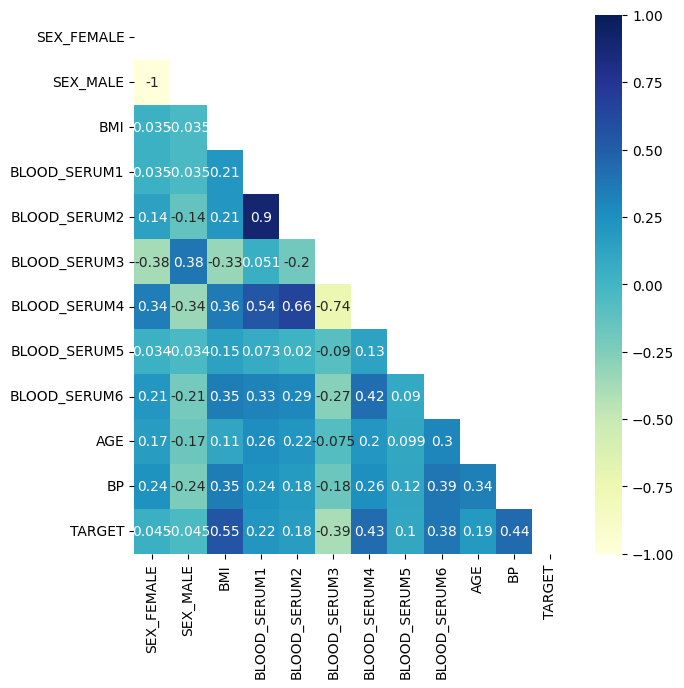

In [23]:
# Generate a mask for the upper triangle
mask = np.triu(np.ones_like(corr_diabetes_pdf, dtype=bool))

# Create a heatmap with the features
plt.figure(figsize=(7, 7))
heatmap = sns.heatmap(corr_diabetes_pdf, mask=mask, cmap="YlGnBu", annot=True, vmin=-1, vmax=1)

We note that several have a decent correlation with the `TARGET` Let's take a look at their relationship a bit closer.

*Note: You will have to convert your Snowpark DF to a Pandas DF in order to use matplotlib & seaborn.*

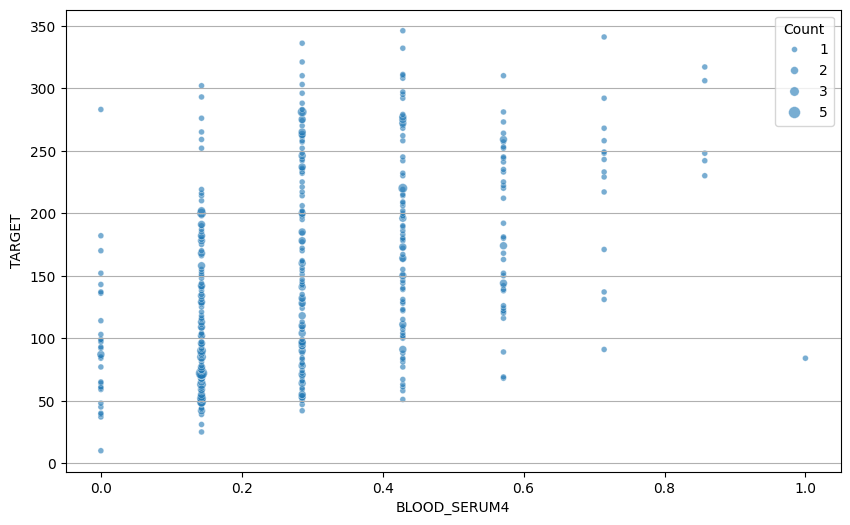

In [ ]:
# As an example, create a scatterplot showing values of BLOOD_SERUM4 against Y.

# Set up a plot to look at BLOOD_SERUM4
counts = transformed_diabetes_df.to_pandas().groupby(['TARGET', 'BLOOD_SERUM4']).size().reset_index(name='Count')

fig, ax = plt.subplots(figsize=(10, 6))

#MyNote: Error in original code with alpha parameter. It needs to be a single value, not a tuple of values. Adjusted to alpha=0.6 for better visualization.
# ax = sns.scatterplot(data=counts, x='BLOOD_SERUM4', y='TARGET', size='Count', markers='o', alpha=(0.1, .25, 0.5, 0.75, 1))
ax = sns.scatterplot(data=counts, x='BLOOD_SERUM4', y='TARGET', size='Count', markers='o', alpha=0.6)
ax.grid(axis='y')

# The relationship looks approximately linear

In [ ]:
session.close()